# 02 · Silver — Transformación, limpieza y control de calidad
Cada transformación se registra con el conteo de filas **antes y después** (`ctl.conteos`). Los registros que
incumplen una regla se **rechazan con su motivo** (`ctl.rechazos`) en vez de corregirse en silencio.

In [1]:
import sys, warnings
from pathlib import Path
RAIZ = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
pd.set_option('display.max_columns', 40); pd.set_option('display.width', 200); pd.set_option('display.max_colwidth', 80)
GOLD, SILVER, CTL = RAIZ/'data'/'gold', RAIZ/'data'/'silver', RAIZ/'data'/'ctl'

## 1. Grano y clave de Silver
Una fila = **valor de un indicador para un año, un territorio, un sexo y un grupo de edad** (+ escenario y edición en proyecciones). Clave natural: `anio + cod_territorio + cod_sexo + cod_edad + cod_indicador`.

In [2]:
h = pd.read_parquet(SILVER/'fact_historico.parquet'); p = pd.read_parquet(SILVER/'fact_proyeccion.parquet')
print('fact_historico', h.shape, '· fact_proyeccion', p.shape)
h.sample(6, random_state=1)[['anio','cod_territorio','cod_sexo','cod_edad','cod_indicador','valor','tipo_dato','estado','fuente','tabla_fuente']]

fact_historico (57054, 14) · fact_proyeccion (111720, 16)


,anio,cod_territorio,cod_sexo,cod_edad,cod_indicador,valor,tipo_dato,estado,fuente,tabla_fuente
24084,2001,37,H,55-59,POBLACION,62096.0,estimado,definitivo,KOSIS,DT_1BPB001
53058,1995,25,T,45-49,POB_CENSO_HIST,67648.0,observado,definitivo,KOSIS,DT_1IN0001
18252,2013,00,H,40-49,TASA_DESEMPLEO,2.0,observado,definitivo,KOSIS,DT_1DA7012S
22260,2002,00,T,10-14,POBLACION,3231727.0,estimado,definitivo,KOSIS,DT_1BPA001
54385,2000,33,H,55-59,POB_CENSO_HIST,30982.0,observado,definitivo,KOSIS,DT_1IN0001
43923,2015,29,M,85+,POBLACION,1376.0,estimado,definitivo,KOSIS,DT_1BPB001


## 2. Transformaciones y conteos antes/después

In [3]:
c = pd.read_parquet(CTL/'conteos.parquet')
c[c.dataset.isin(['eaps_sido','poblacion_sido','censo_registros'])][['dataset','paso','filas_entrada','filas_salida','diferencia','nota']]

,dataset,paso,filas_entrada,filas_salida,diferencia,nota
50,eaps_sido,formato largo (melt),19,6669,6650,351 columnas de periodo/ítem
51,eaps_sido,descartar columnas no anuales (meses) y columnas vacías,6669,4446,-2223,2223 celdas mensuales/fuera de periodo; 0 de columna vacía
52,eaps_sido,selección de variables mapeadas (items_kosis.csv),4446,4446,0,todas las variables mapeadas
53,eaps_sido,excluir unidades territoriales fuera de alcance,4446,4446,0,"0 etiquetas fuera de alcance (Abroad, si-gun-gu, áreas urbanas/rurales, prov..."
54,eaps_sido,excluir agregados de edad redundantes (80+),4446,4446,0,
55,eaps_sido,separar celdas sin dato (no se imputan),4446,4068,-378,378 celdas vacías o '-'
56,eaps_sido,reglas de aceptación,4068,4059,-9,9 rechazados (0.22 %)
72,poblacion_sido,formato largo (melt),1242,67068,65826,54 columnas de periodo/ítem
73,poblacion_sido,descartar columnas no anuales (meses) y columnas vacías,67068,65826,-1242,0 celdas mensuales/fuera de periodo; 1242 de columna vacía
74,poblacion_sido,selección de variables mapeadas (items_kosis.csv),65826,65826,0,todas las variables mapeadas


| # | Transformación | Justificación |
|---|---|---|
| 1 | Formato largo (melt) | Las tablas KOSIS son anchas (un año por columna); el análisis y el modelo dimensional requieren una observación por fila |
| 2 | Sólo periodos anuales | Grano común anual; los meses de EAPS/vitales son otra periodicidad (el promedio anual oficial ya está publicado) |
| 3 | Selección de variables (`items_kosis.csv`) | Se conservan sólo las variables del estudio; el resto queda en Bronze |
| 4 | Homologación (territorio, sexo, edad, escenario) | La misma entidad aparece con nombres distintos (Gangwon/Gangwon-do/Gangwon-State; "35-39 years old"/"35 - 39세") |
| 5 | Territorios fuera de alcance | Si-gun-gu, "Abroad", agregados urbano/rural y provincias anteriores a 1945 no responden las preguntas |
| 6 | Tipos y unidades | Texto → número; miles → personas (×1000); marca preliminar/definitivo desde la propia etiqueta `p)` |
| 7 | Celdas sin dato | Se separan en `sin_dato` con su motivo; **no se imputan** (inventar demografía sesgaría los KPIs) |
| 8 | 85-89…100+ → 85+; se excluye 80+ | Grupo abierto común a todas las fuentes; 80+ duplicaría población |
| 9 | Reglas de aceptación | Integridad referencial, año válido, tipo, rango plausible, unicidad de clave |

## 3. Tratamiento de valores nulos (decisión por variable)

In [4]:
s = pd.read_parquet(SILVER/'sin_dato.parquet')
s.groupby(['cod_indicador','motivo']).size().rename('celdas').reset_index().sort_values('celdas', ascending=False).head(15)

,cod_indicador,motivo,celdas
21,POB_CENSO_HIST,territorio aún no existía como si-do,4818
20,POB_CENSO_HIST,grupo de edad o territorio no publicado en ese censo,3675
15,POBLACION,territorio aún no existía como si-do,792
32,TASA_FEC_EDAD,territorio aún no existía (Sejong < 2012),84
2,DEFUNCIONES,territorio aún no existía como si-do,76
12,NACIMIENTOS,territorio aún no existía como si-do,76
0,CRECIMIENTO_NATURAL,territorio aún no existía como si-do,64
37,TFR,territorio aún no existía como si-do,46
33,TASA_NUPCIALIDAD,territorio aún no existía como si-do,40
5,DIVORCIOS,territorio aún no existía como si-do,40


**Decisión:** ningún valor demográfico se imputa con media, mediana o moda: son conteos y tasas oficiales y un valor
inventado contaminaría los KPIs. El nulo se mantiene cuando tiene interpretación válida (territorio inexistente,
dato aún no publicado). La única "sustitución" es estructural y documentada: el agregado **CNSJ = Chungnam + Sejong**
para comparar 2000-2025, y la elección de DT_1B8000I como maestra regional porque DT_1B8000H no trae 2022.

## 4. Rechazos trazados

In [5]:
r = pd.read_parquet(CTL/'rechazos.parquet')
display(r.groupby(['dataset','regla','motivo']).size().rename('registros').reset_index())
r.head(3)

,dataset,regla,motivo,registros
0,censo_registros,duplicado_clave,clave natural repetida (anio + cod_territorio + cod_sexo + cod_edad + cod_in...,70
1,eaps_sido,integridad_cod_territorio,código fuera de la dimensión cod_territorio (__RECHAZO__),9
2,vitales_sido_mensual,integridad_cod_territorio,código fuera de la dimensión cod_territorio (__RECHAZO__),3


,id_ejecucion,dataset,regla,motivo,registro
0,20261005_225217_d8e876,vitales_sido_mensual,integridad_cod_territorio,código fuera de la dimensión cod_territorio (__RECHAZO__),"{""territorio"": ""Jeonnam-Gwangju"", ""columna"": ""2025 | Live births(persons)"", ..."
1,20261005_225217_d8e876,vitales_sido_mensual,integridad_cod_territorio,código fuera de la dimensión cod_territorio (__RECHAZO__),"{""territorio"": ""Jeonnam-Gwangju"", ""columna"": ""2025 | Deaths(persons)"", ""valo..."
2,20261005_225217_d8e876,vitales_sido_mensual,integridad_cod_territorio,código fuera de la dimensión cod_territorio (__RECHAZO__),"{""territorio"": ""Jeonnam-Gwangju"", ""columna"": ""2025 | Total Fertility Rate(pe..."


## 5. Reglas de consistencia (no rechazan; dejan evidencia)

In [6]:
v = pd.read_parquet(CTL/'validaciones.parquet')
v[v.tipo=='consistencia'][['dataset','regla','evaluados','afectados','resultado','detalle']]

,dataset,regla,evaluados,afectados,resultado,detalle
253,vitales_sigungu,suma_sido_igual_nacional,52,0,PASA,Σ 17 si-do (DT_1B8000I) = nacional (DT_1B8000F); tolerancia ±0.5 %; dif. máx...
254,nacimientos_sexo,hombres_mas_mujeres_igual_total,1164,0,PASA,H + M = T; tolerancia ±0.5 %; dif. máx 0.000 %
255,vitales_nacional,identidad_crecimiento_natural,56,0,PASA,crecimiento natural = nacimientos - defunciones; tolerancia ±0.5; dif. máx 0...
256,poblacion_nacional,suma_edades_igual_total,219,0,PASA,Σ grupos quinquenales (85+ agregado) = total; tolerancia ±0.5 %; dif. máx 0....
257,poblacion_nacional,hombres_mas_mujeres_igual_total,1387,0,PASA,H + M = T; tolerancia ±0.5 %; dif. máx 0.000 %
258,poblacion_sido,suma_edades_igual_total,2826,0,PASA,Σ grupos quinquenales (85+ agregado) = total; tolerancia ±0.5 %; dif. máx 0....
259,poblacion_sido,hombres_mas_mujeres_igual_total,17898,0,PASA,H + M = T; tolerancia ±0.5 %; dif. máx 0.000 %
260,proyeccion_escenarios,suma_edades_igual_total,4284,0,PASA,Σ grupos quinquenales (85+ agregado) = total; tolerancia ±0.5 %; dif. máx 0....
261,proyeccion_escenarios,hombres_mas_mujeres_igual_total,27132,0,PASA,H + M = T; tolerancia ±0.5 %; dif. máx 0.000 %
262,poblacion_sido,suma_sido_igual_nacional,159,0,PASA,Σ 17 si-do = Whole country; tolerancia ±0.5 %; dif. máx 0.000 %


## 6. Conciliación fuente maestra vs contraste (una fuente maestra por indicador)

In [7]:
k = pd.read_parquet(GOLD/'fact_conciliacion.parquet')
k = k[k.comparable & k.anio.between(2000, 2025)]
k.groupby(['tipo_comparacion','cod_indicador','fuente_contraste']).agg(pares=('dif_pct','size'),
    dentro_tolerancia=('dentro_tolerancia','mean'), dif_max_pct=('dif_pct', lambda s: s.abs().max())).round(3)

pares  dentro_tolerancia  dif_max_pct
tipo_comparacion     cod_indicador            fuente_contraste                                       
dato publicado       CRECIMIENTO_NATURAL      KOSIS               825                1.0          0.0
                     DEFUNCIONES              KOSIS              1281                1.0          0.0
                     DESOCUPADOS              KOSIS                26                1.0          0.0
                     DIVORCIOS                KOSIS               411                1.0          0.0
                     ESPERANZA_VIDA           WB                   25                1.0        0.172
                     INACTIVOS                KOSIS                26                1.0          0.0
                     MATRIMONIOS              KOSIS               411                1.0          0.0
                     NACIMIENTOS              KOSIS              1281                1.0          0.0
                                              OECD                 25                1.0          0.0
                     OCUPADOS                 KOSIS                26                1.0          0.0
                                              OECD                 26                1.0        0.002
                     POBLACION                KOSIS              1315                1.0          0.0
                                              WB                   92                1.0        2.771
                     POB_15MAS                KOSIS                26                1.0          0.0
                     POB_ACTIVA               KOSIS                26                1.0          0.0
                                              OECD                 26                1.0        0.002
                     TASA_BRUTA_MORTALIDAD    KOSIS               411                1.0          0.0
                     TASA_BRUTA_NATALIDAD     KOSIS               411                1.0          0.0
                     TASA_CRECIMIENTO_NATURAL KOSIS               411                1.0          0.0
                     TASA_DESEMPLEO           KOSIS                26                1.0          0.0
                                              OECD                 26                1.0        1.823
                     TASA_DIVORCIALIDAD       KOSIS               411                1.0          0.0
                     TASA_EMPLEO              KOSIS                26                1.0          0.0
                     TASA_NUPCIALIDAD         KOSIS               411                1.0          0.0
                     TASA_PARTICIPACION       KOSIS                26                1.0          0.0
                     TFR                      KOSIS               893                1.0        0.639
                                              OECD                 25                1.0          0.0
                                              WB                   25                1.0          0.0
fórmula del pipeline DEP_JUVENIL              KOSIS                 4                1.0        0.291
                     DEP_TOTAL                KOSIS                 4                1.0        0.102
                     DEP_VEJEZ                KOSIS                 4                1.0        0.175
                                              WB                   26              0.962        3.527
                     IND_ENVEJECIMIENTO       KOSIS                 4                1.0        0.021
                     PROP_15_64               KOSIS                 4                1.0        0.029
                     PROP_65MAS               KOSIS                 4                1.0        0.256
                                              WB                   26                1.0        2.771

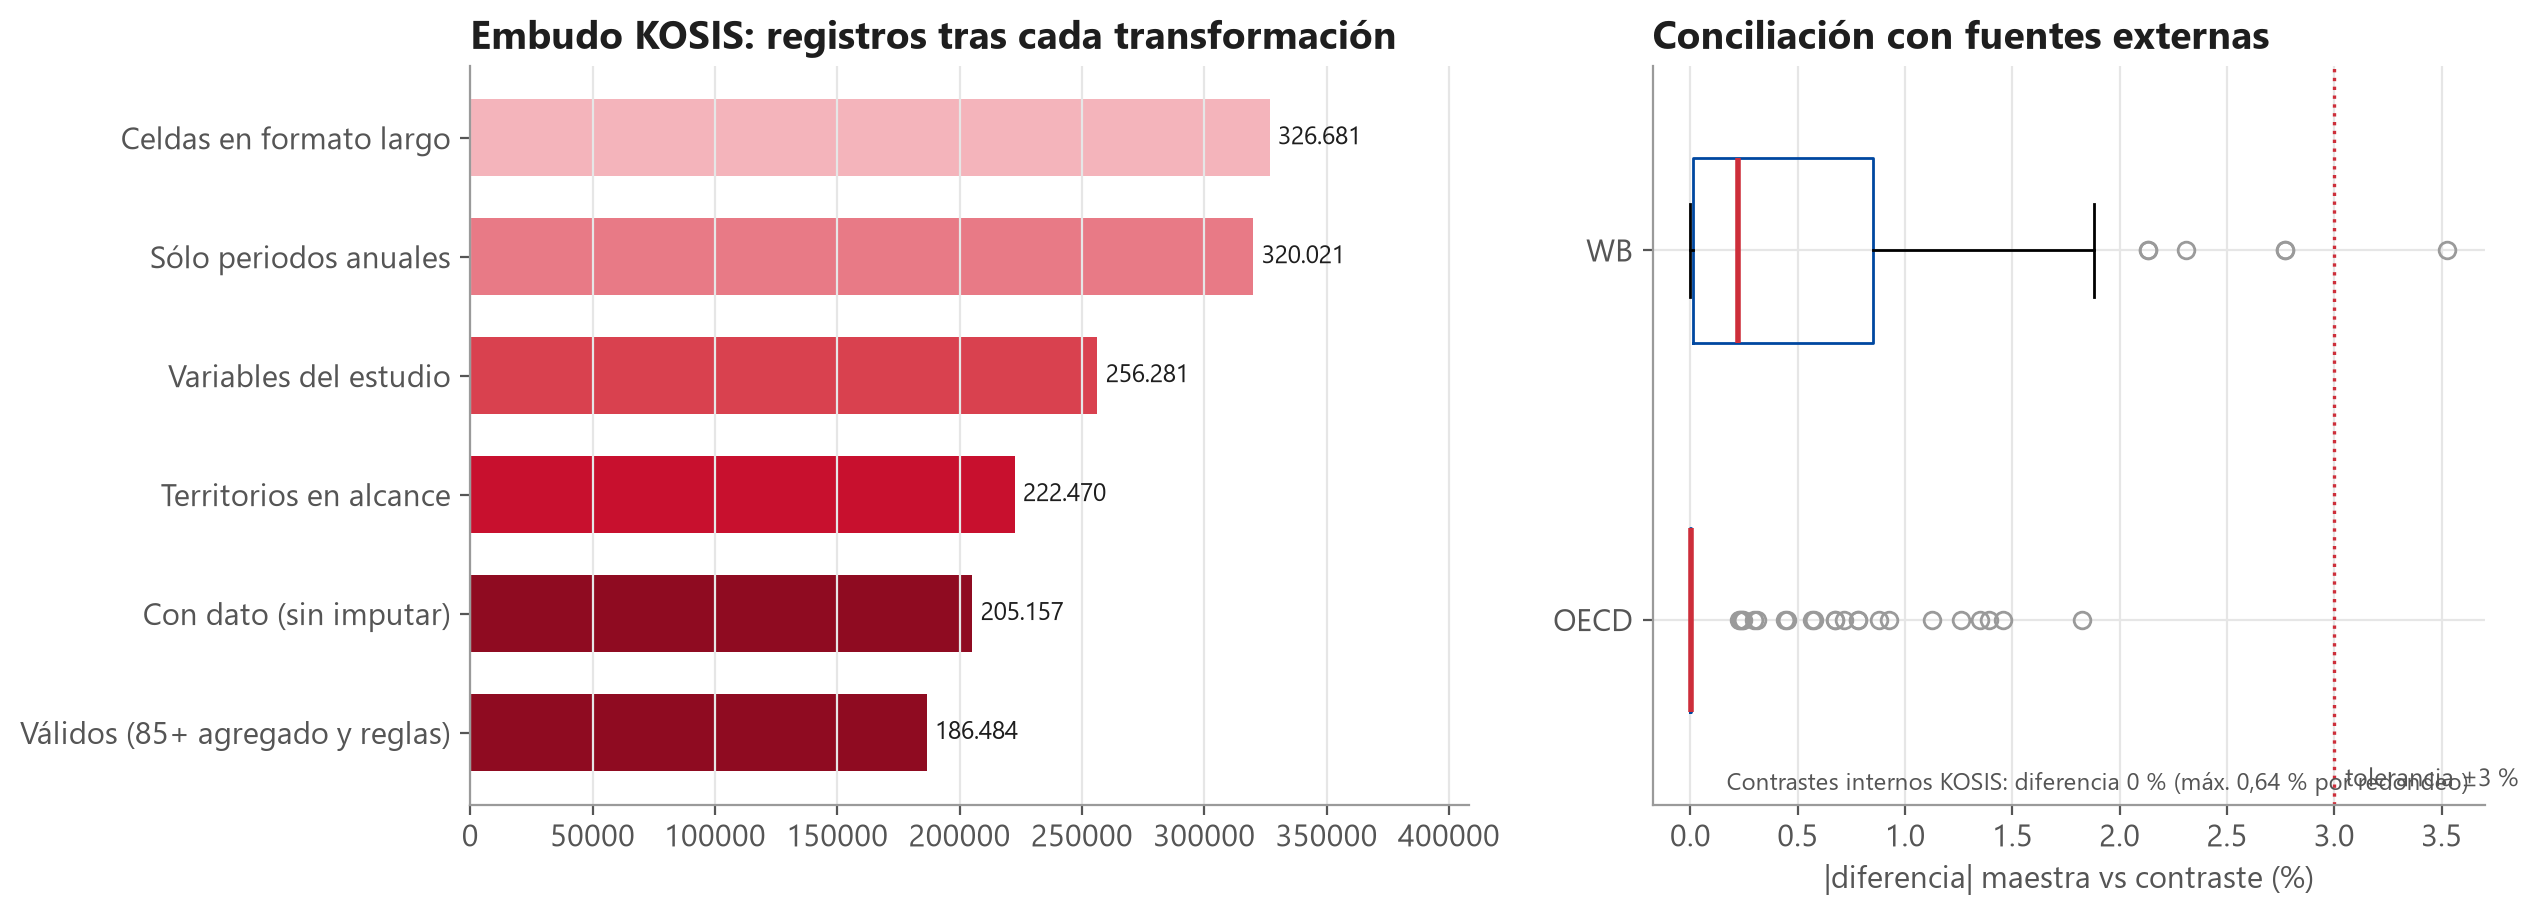

In [8]:
display(Image(str(RAIZ/'docs'/'figuras'/'13_calidad_pipeline.png')))

**Lectura:** las fórmulas del pipeline reproducen los indicadores oficiales de KOSTAT (dependencia, envejecimiento,
% 65+) con diferencias < 0,4 %. Frente al Banco Mundial la dependencia de vejez difiere hasta 3,5 % porque el Banco
Mundial usa las estimaciones de población de la ONU, no las de KOSTAT: es una diferencia de **fuente**, no de cálculo,
y por eso KOSTAT es la fuente maestra.